<a href="https://colab.research.google.com/github/rebeccaastaix/Dissertation-Supplementary-Materials/blob/main/Graph2%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

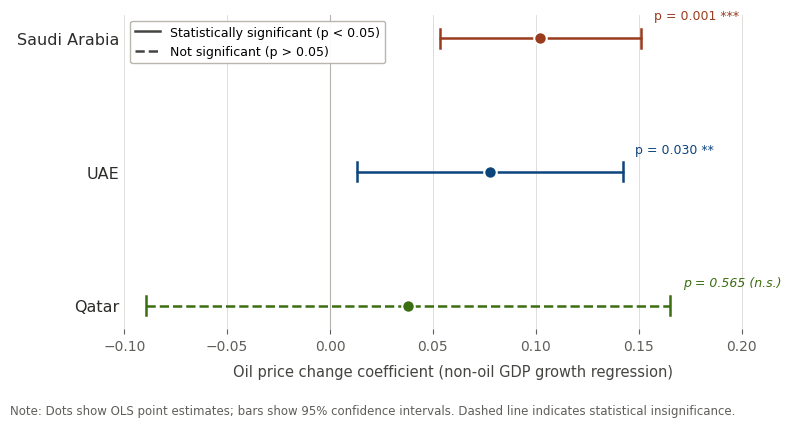

Saved as graph2_oil_sensitivity.png


In [13]:
import matplotlib.lines as mlines

countries = ['Saudi Arabia', 'UAE', 'Qatar']
coefficients = [0.1023, 0.0777, 0.0380]
std_errors = [0.025, 0.033, 0.065]
ci_lower = [c - 1.96 * se for c, se in zip(coefficients, std_errors)]
ci_upper = [c + 1.96 * se for c, se in zip(coefficients, std_errors)]
colors = ['#993C1D', '#0C447C', '#3B6D11']
sig_labels = ['p = 0.001 ***', 'p = 0.030 **', 'p = 0.565 (n.s.)']

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.axvline(x=0, color='#888780', linewidth=0.8, linestyle='-', alpha=0.5, zorder=1)

y_pos = [2, 1, 0]

for i, (country, coef, lo, hi, col, y, sig) in enumerate(
        zip(countries, coefficients, ci_lower, ci_upper, colors, y_pos, sig_labels)):

    is_sig = i < 2
    ls = '-' if is_sig else '--'

    ax.plot([lo, hi], [y, y],
            color=col, linewidth=1.8, linestyle=ls,
            solid_capstyle='round', zorder=2)
    ax.plot([lo, lo], [y - 0.07, y + 0.07], color=col, linewidth=1.8, zorder=3)
    ax.plot([hi, hi], [y - 0.07, y + 0.07], color=col, linewidth=1.8, zorder=3)

    ax.plot(coef, y,
            marker='o', markersize=9,
            color=col, markerfacecolor=col,
            markeredgecolor='white', markeredgewidth=1.5,
            zorder=4)

    ax.text(hi + 0.006, y + 0.12,
            sig, fontsize=9, color=col,
            va='bottom', ha='left', style='italic' if not is_sig else 'normal')

ax.set_yticks(y_pos)
ax.set_yticklabels(countries, fontsize=11.5, color='#2C2C2A')
ax.set_xlabel('Oil price change coefficient (non-oil GDP growth regression)',
              fontsize=10.5, color='#444441', labelpad=8)
ax.set_xlim(-0.10, 0.22)
ax.tick_params(axis='x', labelsize=10, colors='#5F5E5A')
ax.tick_params(axis='y', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis='x', color='#B4B2A9', linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

solid_line = mlines.Line2D([], [], color='#444441', linewidth=1.8,
                            linestyle='-', label='Statistically significant (p < 0.05)')
dashed_line = mlines.Line2D([], [], color='#444441', linewidth=1.8,
                             linestyle='--', label='Not significant (p > 0.05)')
ax.legend(handles=[solid_line, dashed_line],
          fontsize=9, frameon=True, framealpha=0.95,
          edgecolor='#B4B2A9', facecolor='white',
          loc='upper left')

fig.text(0.01, -0.05,
         'Note: Dots show OLS point estimates; bars show 95% confidence intervals. '
         'Dashed line indicates statistical insignificance.',
         fontsize=8.5, color='#5F5E5A', ha='left')

plt.tight_layout()
plt.savefig('graph2_oil_sensitivity.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved as graph2_oil_sensitivity.png")

In [5]:
from google.colab import files
uploaded = files.upload()

Saving UAE_merged_dataset.xlsx to UAE_merged_dataset.xlsx


In [6]:
from google.colab import files
uploaded = files.upload()

Saving Saudi_Arabia_merged_dataset.xlsx to Saudi_Arabia_merged_dataset.xlsx


In [7]:
from google.colab import files
uploaded = files.upload()

Saving Qatar_merged_dataset.xlsx to Qatar_merged_dataset.xlsx


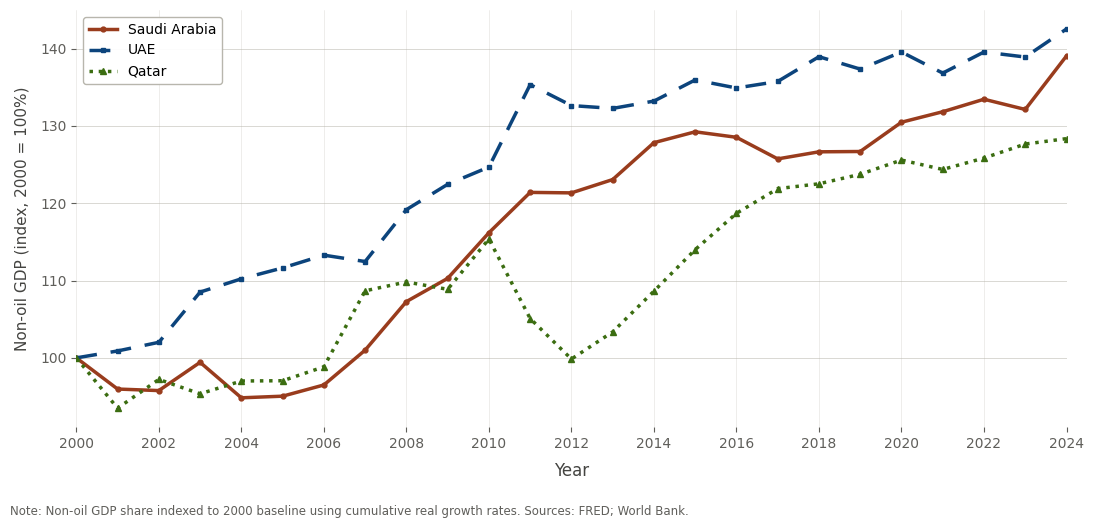

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

sa = pd.read_excel('Saudi_Arabia_merged_dataset.xlsx', sheet_name='Saudi_Model_Data')
sa = sa[['Year', 'Non-Oil Real GDP Growth (%)', 'Saudi Arabia Total GDP Growth (annual %)']].dropna()
sa.columns = ['Year', 'nonoil_growth', 'total_growth']

uae = pd.read_excel('UAE_merged_dataset.xlsx', sheet_name='UAE_Model_Data')
uae = uae[['Year', 'Non-Oil Real GDP Growth (%)', 'UAE Total GDP Growth (annual %)']].dropna()
uae.columns = ['Year', 'nonoil_growth', 'total_growth']

qa = pd.read_excel('Qatar_merged_dataset.xlsx', sheet_name='Qatar_Model_Data')
qa = qa[['Year', 'Non-Oil Real GDP Growth (%)', 'Qatar Total GDP Growth (annual %)']].dropna()
qa.columns = ['Year', 'nonoil_growth', 'total_growth']

def compute_share(df, base_year=2000):
    df = df.sort_values('Year').reset_index(drop=True)
    nonoil_idx = 100.0
    total_idx = 100.0
    shares = []
    for _, row in df.iterrows():
        shares.append(nonoil_idx / total_idx * 100)
        nonoil_idx *= (1 + row['nonoil_growth'] / 100)
        total_idx  *= (1 + row['total_growth']  / 100)
    df['nonoil_share'] = shares
    return df

sa  = compute_share(sa)
uae = compute_share(uae)
qa  = compute_share(qa)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(sa['Year'],  sa['nonoil_share'],
        color='#993C1D', linewidth=2.5, marker='o', markersize=3.5,
        markerfacecolor='#993C1D', label='Saudi Arabia')
ax.plot(uae['Year'], uae['nonoil_share'],
        color='#0C447C', linewidth=2.5, marker='s', markersize=3.5,
        markerfacecolor='#0C447C', linestyle='--', dashes=(6,4), label='UAE')
ax.plot(qa['Year'],  qa['nonoil_share'],
        color='#3B6D11', linewidth=2.5, marker='^', markersize=4,
        markerfacecolor='#3B6D11', linestyle=':', label='Qatar')

ax.set_xlabel('Year', fontsize=12, color='#444441', labelpad=8)
ax.set_ylabel('Non-oil GDP (index, 2000 = 100%)', fontsize=11, color='#444441', labelpad=8)
ax.tick_params(axis='both', labelsize=10, colors='#5F5E5A')

all_years = sorted(set(sa['Year'].tolist() + uae['Year'].tolist() + qa['Year'].tolist()))
ax.set_xlim(min(all_years), max(all_years))
ax.set_xticks(range(int(min(all_years)), int(max(all_years))+1, 2))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis='y', color='#B4B2A9', linewidth=0.5, alpha=0.7)
ax.grid(axis='x', color='#B4B2A9', linewidth=0.4, alpha=0.4)
ax.set_axisbelow(True)

ax.legend(fontsize=10, frameon=True, framealpha=0.95,
          edgecolor='#B4B2A9', facecolor='white', loc='upper left')

fig.text(0.01, -0.04,
         'Note: Non-oil GDP share indexed to 2000 baseline using cumulative real growth rates. '
         'Sources: FRED; World Bank.',
         fontsize=8.5, color='#5F5E5A', ha='left')

plt.tight_layout()
plt.savefig('graph3_nonoil_share.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
